In [1]:
import pandas as pd
import numpy as np
import io

print("Step 1: Reading and Cleaning the Raw Text File...")

# 1. File ko path halne (timro Kaggle ma vako path)
file_path = '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_586.txt' # Yaha aafno file ko exact naam hala

# 2. File lai line-by-line padhne
with open(file_path, 'r') as file:
    lines = file.readlines()

# 3. SMART FILTER: Jun line ma kamma (',') cha, tyo matra asali data ho!
# Baki sabai mathi ko kachara (text, years) automatic ignore huncha.
clean_lines = [line for line in lines if ',' in line]

# 4. Tyo safa lines lai eutai text block ma jodne
clean_text = "".join(clean_lines)

# 5. Pandas lai sidhai CSV jasari padhna lagaune (io.StringIO le text lai file jasto banaucha)
# Hamro data ma header chaina, tesaile aafai naam dine: 'dateTime' ra 'value'
df = pd.read_csv(io.StringIO(clean_text), header=None, names=['dateTime', 'value'])

# 6. Date format milaune (01/Jan/2006 lai Python le bujhne datetime banaune)
df['dateTime'] = pd.to_datetime(df['dateTime'], format='%d/%b/%Y')

# 7. DateTime lai index banaune (Time-series ko lagi jaruri)
df.set_index('dateTime', inplace=True)

print("✅ Data Loaded Successfully! Kachara text hatiskayo.")
print("\nFirst 5 rows of clean DataFrame:")
print(df.head())
print(f"\nTotal Data Points: {len(df)}")

Step 1: Reading and Cleaning the Raw Text File...
✅ Data Loaded Successfully! Kachara text hatiskayo.

First 5 rows of clean DataFrame:
            value
dateTime         
2014-01-01   1.56
2014-01-02   1.56
2014-01-03   1.55
2014-01-04   1.55
2014-01-05   1.55

Total Data Points: 3467


In [2]:
df.describe()

,value
count,3467.000000
mean,2.494554
std,0.748293
min,0.000000
25%,1.980000
50%,2.340000
75%,2.870000
max,10.330000


--- OUTLIER INVESTIGATION ---


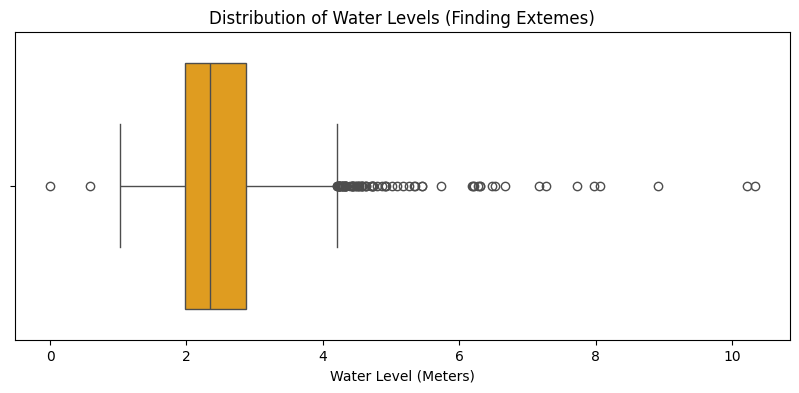


Mathematical Normal Range: 0.64m to 4.21m

--- TOP 10 LOWEST VALUES (Potential Sensor Drops) ---
            value
dateTime         
2015-07-17   0.00
2016-12-31   0.58
2018-12-31   1.03
2015-12-31   1.22
2014-04-24   1.30
2014-04-25   1.30
2014-04-26   1.30
2014-05-19   1.30
2014-05-20   1.30
2014-05-24   1.30

--- TOP 10 HIGHEST VALUES (Potential Floods or Glitches) ---
            value
dateTime         
2023-08-08  10.33
2019-07-12  10.22
2014-08-14   8.92
2021-07-03   8.06
2017-08-13   7.97
2019-07-13   7.73
2021-08-27   7.27
2020-07-21   7.17
2022-06-29   6.67
2021-07-01   6.53


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- OUTLIER INVESTIGATION ---")

# 1. Boxplot (Visualizing the extremes)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['value'], color='orange')
plt.title('Distribution of Water Levels (Finding Extemes)')
plt.xlabel('Water Level (Meters)')
plt.show()

# 2. IQR Method to find mathematical outliers
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nMathematical Normal Range: {lower_bound:.2f}m to {upper_bound:.2f}m")

# 3. Let's look at the SUSPICIOUS LOWS (Top 10 lowest values)
print("\n--- TOP 10 LOWEST VALUES (Potential Sensor Drops) ---")
print(df.nsmallest(10, 'value')[['value']])

# 4. Let's look at the EXTREME HIGHS (Floods vs Errors)
print("\n--- TOP 10 HIGHEST VALUES (Potential Floods or Glitches) ---")
print(df.nlargest(10, 'value')[['value']])

In [4]:
import pandas as pd
import numpy as np

print("--- STEP 1: REMOVING THE ZERO GLITCH ---")
# Tyo 0.00 meter (ya tyo bhanda tala ko kunai negative glitch) lai NaN banaune
df.loc[df['value'] <= 0.0, 'value'] = np.nan
print("✅ Sensor zero glitches replaced with NaN.")

print("\n--- STEP 2: FORCING A UNIFORM TIMELINE ---")
# 1. Hamro data ko suru ko din ra last ko din nikalne
start_date = df.index.min()
end_date = df.index.max()
print(f"Data Timeline: From {start_date.date()} to {end_date.date()}")

# 2. Euta perfect, continuous calendar banaune (1 day frequency)
full_timeline = pd.date_range(start=start_date, end=end_date, freq='D')

# 3. Hamro data lai yo perfect calendar sanga align (reindex) garne
# Jun din DHM le data deko chaina, tyaha Pandas le aafai NaN haldincha
df_uniform = df.reindex(full_timeline)
df_uniform.index.name = 'dateTime'

print("\n--- TIMELINE REPORT ---")
print(f"Original Data Points       : {len(df)}")
print(f"Uniform Timeline Points    : {len(df_uniform)}")
# Jati difference cha, teti ota 'hidden gaps' data ma thiyo
missing_days = df_uniform['value'].isna().sum()
print(f"Total Missing Days (NaNs)  : {missing_days}")

print("\n✅ Perfect Uniform Timeline Ready!")

--- STEP 1: REMOVING THE ZERO GLITCH ---
✅ Sensor zero glitches replaced with NaN.

--- STEP 2: FORCING A UNIFORM TIMELINE ---
Data Timeline: From 2014-01-01 to 2023-12-31

--- TIMELINE REPORT ---
Original Data Points       : 3467
Uniform Timeline Points    : 3652
Total Missing Days (NaNs)  : 186

✅ Perfect Uniform Timeline Ready!


In [5]:
import numpy as np

print("--- STEP 3: SMART INTERPOLATION ---")
# 7 din samma ko gap (NaNs) lai linear interpolation le fill garne. 
# 7 din bhanda badi gap cha bhane teslai khali (NaN) chhod-dine.
gap_limit_days = 7
df_uniform['value'] = df_uniform['value'].interpolate(method='linear', limit=gap_limit_days)
print(f"Interpolation completed. Short gaps (<{gap_limit_days} days) filled.")


print("\n--- STEP 4: CHUNKING ALGORITHM (Breaking at Long Gaps) ---")
# Aba remaining NaNs (jun 7 din vanda lamo thiyo) ma data lai break garchau
def get_clean_chunks(df, min_len):
    chunks = []
    current_chunk = []
    for val in df['value'].values:
        if pd.notna(val):
            current_chunk.append(val)
        else:
            if len(current_chunk) > min_len:
                chunks.append(np.array(current_chunk))
            current_chunk = []
    if len(current_chunk) > min_len:
        chunks.append(np.array(current_chunk))
    return chunks

# Hamro daily lag time 10 days hune vako le, 10 din vanda sano chunk discard garchau
time_step = 10 
chunks = get_clean_chunks(df_uniform, min_len=time_step)

print(f"Data successfully split into {len(chunks)} continuous, safe chunks.")
for i in range(min(3, len(chunks))):
    print(f"  -> Chunk {i+1}: {len(chunks[i])} continuous days")

--- STEP 3: SMART INTERPOLATION ---
Interpolation completed. Short gaps (<7 days) filled.

--- STEP 4: CHUNKING ALGORITHM (Breaking at Long Gaps) ---
Data successfully split into 3 continuous, safe chunks.
  -> Chunk 1: 780 continuous days
  -> Chunk 2: 665 continuous days
  -> Chunk 3: 2040 continuous days


In [6]:
import numpy as np

print("--- STEP 5.1: CHRONOLOGICAL TRAIN/TEST SPLIT (80/20) ---")

# Function to safely cut chunks at the 80% timeline mark
def split_chunks_chronologically(chunks_list, split_ratio=0.85):
    total_days = sum(len(c) for c in chunks_list)
    split_point = int(total_days * split_ratio)
    
    train_chunks = []
    test_chunks = []
    current_days = 0
    
    for chunk in chunks_list:
        chunk_len = len(chunk)
        
        # Condition 1: Pura chunk train ma jancha
        if current_days + chunk_len <= split_point:
            train_chunks.append(chunk)
            current_days += chunk_len
            
        # Condition 2: Chunk lai thakkai bich bata katnu parcha
        elif current_days < split_point:
            cut_idx = split_point - current_days
            train_chunks.append(chunk[:cut_idx])
            test_chunks.append(chunk[cut_idx:])
            current_days += chunk_len
            
        # Condition 3: Baki sabai chunks test (future) ma jancha
        else:
            test_chunks.append(chunk)
            
    return train_chunks, test_chunks

# Applying the split to Bagmati chunks
bagmati_train_chunks, bagmati_test_chunks = split_chunks_chronologically(chunks, split_ratio=0.8)

print(f"Total Original Days : {sum(len(c) for c in chunks)}")
print(f"Train Days (80%)    : {sum(len(c) for c in bagmati_train_chunks)}")
print(f"Test Days (20%)     : {sum(len(c) for c in bagmati_test_chunks)}")

--- STEP 5.1: CHRONOLOGICAL TRAIN/TEST SPLIT (80/20) ---
Total Original Days : 3485
Train Days (80%)    : 2788
Test Days (20%)     : 697


In [7]:
from sklearn.preprocessing import MinMaxScaler

print("\n--- STEP 5.2: LEAK-PROOF NORMALIZATION ---")

# 1. Fit Scaler strictly on TRAIN data only (Blinding it from the future)
train_combined = np.concatenate(bagmati_train_chunks).reshape(-1, 1)
bagmati_scaler = MinMaxScaler(feature_range=(0, 1))
bagmati_scaler.fit(train_combined)

# 2. Transform BOTH Train and Test chunks using the Train-fitted scaler
scaled_train_chunks = [bagmati_scaler.transform(c.reshape(-1, 1)) for c in bagmati_train_chunks]
scaled_test_chunks = [bagmati_scaler.transform(c.reshape(-1, 1)) for c in bagmati_test_chunks]

print("✅ Bagmati Normalization Complete!")
print(f"Scaler Min: {bagmati_scaler.data_min_[0]:.2f}, Max: {bagmati_scaler.data_max_[0]:.2f}")


--- STEP 5.2: LEAK-PROOF NORMALIZATION ---
✅ Bagmati Normalization Complete!
Scaler Min: 0.58, Max: 10.22


In [8]:
print("\n--- STEP 6: SEQUENCE EXTRACTION & VAULT STORAGE ---")

time_step = 10 

def extract_windows(scaled_chunks_list, time_step):
    X_list, y_list = [], []
    for chunk in scaled_chunks_list:
        # Check if chunk is large enough to create at least one window
        if len(chunk) > time_step:
            for i in range(len(chunk) - time_step):
                X_list.append(chunk[i:(i + time_step), 0])
                y_list.append(chunk[i + time_step, 0])
    return np.array(X_list), np.array(y_list)

# Generate Train Sequences
X_train_bagmati, y_train_bagmati = extract_windows(scaled_train_chunks, time_step)
X_train_bagmati = X_train_bagmati.reshape(X_train_bagmati.shape[0], X_train_bagmati.shape[1], 1)

# Generate Test Sequences
X_test_bagmati, y_test_bagmati = extract_windows(scaled_test_chunks, time_step)
X_test_bagmati = X_test_bagmati.reshape(X_test_bagmati.shape[0], X_test_bagmati.shape[1], 1)

# Store everything in a master dictionary for Bagmati
bagmati_vault = {
    'train': (X_train_bagmati, y_train_bagmati),
    'test': (X_test_bagmati, y_test_bagmati),
    'scaler': bagmati_scaler
}

print("✅ Bagmati Vault Successfully Created!")
print("-" * 50)
print(f"Train Shape: X={X_train_bagmati.shape}, y={y_train_bagmati.shape}")
print(f"Test Shape : X={X_test_bagmati.shape}, y={y_test_bagmati.shape}")
print("-" * 50)

# Optional: Clean up memory
del chunks
del bagmati_train_chunks
del bagmati_test_chunks
del scaled_train_chunks
del scaled_test_chunks


--- STEP 6: SEQUENCE EXTRACTION & VAULT STORAGE ---
✅ Bagmati Vault Successfully Created!
--------------------------------------------------
Train Shape: X=(2758, 10, 1), y=(2758,)
Test Shape : X=(687, 10, 1), y=(687,)
--------------------------------------------------


In [9]:
import pandas as pd
import io

print("--- STEP 1: SMART PARALLEL LOADING (TXT & CSV Supported) ---")

# Timro station IDs ra exact file names (Kaggle ko path anusar update gara)
sunkoshi_stations = {
    '630': '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_630.txt',   # TXT format
    '652': '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_652.txt',   # TXT format
    '665': '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/665 Water Level Inst from 2019-01-01 to 2026-06-15.csv'    # CSV format
}

# Yo naya dictionary le Sunkoshi ko data lai Bagmati vanda 100% separate rakhcha
sunkoshi_raw_data = {}

for station_id, filepath in sunkoshi_stations.items():
    print(f"\nReading Station {station_id} from {filepath}...")
    try:
        # FORMAT 1: Handle TXT files with metadata headers
        if filepath.lower().endswith('.txt'):
            with open(filepath, 'r') as file:
                clean_lines = [line for line in file.readlines() if ',' in line]
            clean_text = "".join(clean_lines)
            df = pd.read_csv(io.StringIO(clean_text), header=None, names=['dateTime', 'value'])
            # TXT ko date format '01/Jan/2006' jasto huncha
            df['dateTime'] = pd.to_datetime(df['dateTime'], format='%d/%b/%Y', errors='coerce')

        # FORMAT 2: Handle standard CSV files
        elif filepath.lower().endswith('.csv'):
            df = pd.read_csv(filepath)
            # CSV ma header farak huna sakcha (e.g., 'Date', 'WaterLevel'). 
            # Safe huna ko lagi suru ko 2 wata column lai 'dateTime' ra 'value' manam
            df = df.iloc[:, [0, 1]] 
            df.columns = ['dateTime', 'value']
            # Pandas lai aafai date format guess garna dine
            df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
        
        else:
            print(f"⚠️ Warning: {filepath} ko format milena. Skipping...")
            continue

        # COMMON CLEANUP FOR BOTH FORMATS
        # 1. Khali dates ya values falne
        df.dropna(subset=['dateTime', 'value'], inplace=True)
        # 2. Value lai strictly Number (float) banaune taaki text naveti-os
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df.dropna(subset=['value'], inplace=True)
        # 3. Index set garne ra date anusar sort garne
        df.set_index('dateTime', inplace=True)
        df.sort_index(inplace=True)
        
        # Finally, safely dictionary ma save garne
        sunkoshi_raw_data[station_id] = df
        
        print(f"✅ Station {station_id} Locked & Loaded: {len(df)} records found.")
        
    except FileNotFoundError:
        print(f"❌ Error: {filepath} not found in Kaggle! Check the name again.")
    except Exception as e:
        print(f"❌ Error processing Station {station_id}: {e}")

print("\n-----------------------------------------------------------")
print("✅ All Sunkoshi data safely isolated in 'sunkoshi_raw_data'.")
print("Bagmati data remains completely untouched and safe.")
print("-----------------------------------------------------------")

--- STEP 1: SMART PARALLEL LOADING (TXT & CSV Supported) ---

Reading Station 630 from /kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_630.txt...
✅ Station 630 Locked & Loaded: 3471 records found.

Reading Station 652 from /kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_652.txt...
✅ Station 652 Locked & Loaded: 3606 records found.

Reading Station 665 from /kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/665 Water Level Inst from 2019-01-01 to 2026-06-15.csv...
✅ Station 665 Locked & Loaded: 312837 records found.

-----------------------------------------------------------
✅ All Sunkoshi data safely isolated in 'sunkoshi_raw_data'.
Bagmati data remains completely untouched and safe.
-----------------------------------------------------------


In [10]:
sunkoshi_raw_data["665"].describe()

,value
count,312837.000000
mean,2.221889
std,1.529267
min,0.000000
25%,0.977001
50%,1.735000
75%,3.262001
max,14.109000


--- DEEP DIVE: ANALYZING 'OUTLIERS' BEFORE DELETING ---

🔍 Station 652: Values above 7.0m
Top 5 Highest Records (Check Dates for continuity):
            value
dateTime         
2007-09-06   7.33
2018-08-15   7.33
2007-09-05   7.32
2018-08-08   7.30
2015-08-17   7.07


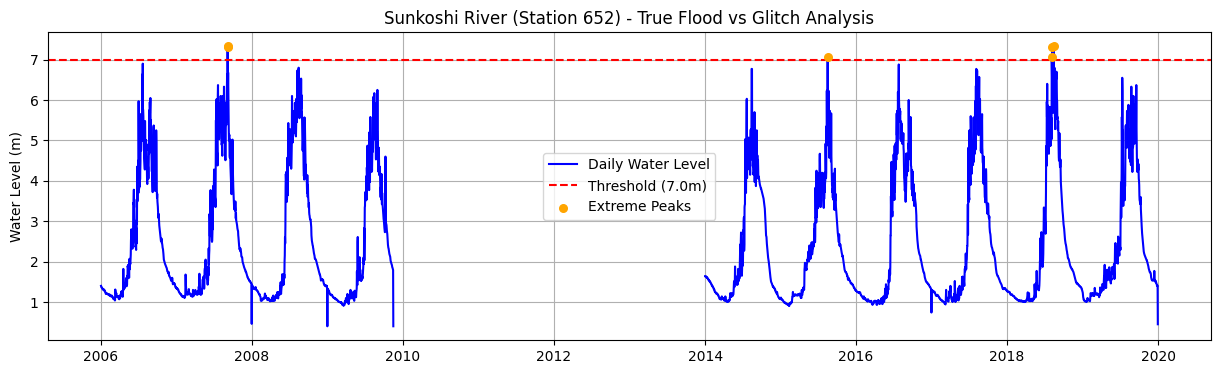


🔍 Station 665: Values above 7.0m
Top 5 Highest Records (Check Dates for continuity):
               value
dateTime            
2024-09-28  9.787457
2023-08-25  7.178924
2025-04-07  7.108001


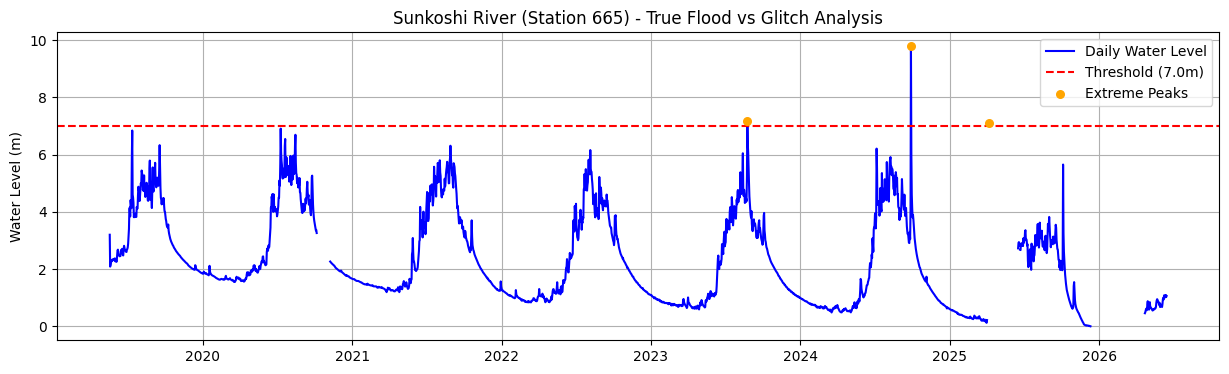


🔍 Station 630: Values above 7.0m
Top 5 Highest Records (Check Dates for continuity):
Empty DataFrame
Columns: [value]
Index: []


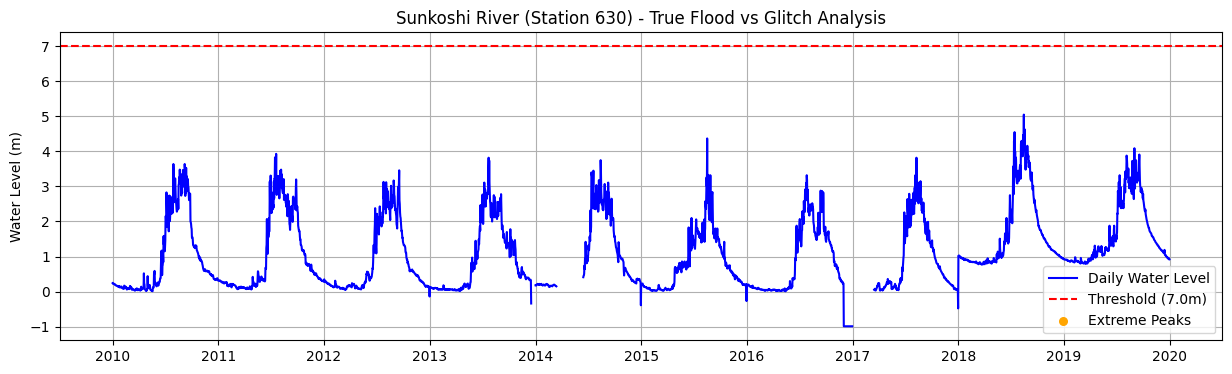

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- DEEP DIVE: ANALYZING 'OUTLIERS' BEFORE DELETING ---")

def inspect_extreme_peaks(df, station_id, threshold):
    print(f"\n🔍 Station {station_id}: Values above {threshold}m")
    
    # 1. Paila daily resample garau (taaki raw 10-min noise hato)
    df_daily = df[['value']].resample('D').mean()
    
    # 2. Extract values above threshold
    high_values = df_daily[df_daily['value'] > threshold]
    
    # if high_values.empty:
    #     print(f"No values above threshold.")
    #     return

    # 3. Print the top 5 highest to see if they are isolated days or continuous
    top_5 = high_values.nlargest(5, 'value')
    print("Top 5 Highest Records (Check Dates for continuity):")
    print(top_5)

    # 4. Plot the whole series with the threshold line to see context
    plt.figure(figsize=(15, 4))
    plt.plot(df_daily.index, df_daily['value'], color='blue', label='Daily Water Level')
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold}m)')
    
    # Highlight the extreme peaks in orange
    plt.scatter(high_values.index, high_values['value'], color='orange', s=30, label='Extreme Peaks', zorder=5)

    plt.title(f'Sunkoshi River (Station {station_id}) - True Flood vs Glitch Analysis')
    plt.ylabel('Water Level (m)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the inspection for the most problematic stations
inspect_extreme_peaks(sunkoshi_raw_data['652'], '652', threshold=7.0)
inspect_extreme_peaks(sunkoshi_raw_data['665'], '665', threshold=7.0)
inspect_extreme_peaks(sunkoshi_raw_data['630'], '630', threshold=7.0)


In [12]:
import pandas as pd
import numpy as np

print("--- RE-RUNNING CLEANING WITH SMART HYDROLOGICAL LIMITS ---")

# Define our absolute safe boundaries
ABSOLUTE_MIN = 0.01  # Zero or negative is always a sensor glitch
ABSOLUTE_MAX = 12.0 # Anything above 12m in Sunkoshi is likely a sensor error

for station_id, df in sunkoshi_raw_data.items():
    # 1. Resampling to Daily Mean (Harmonization)
    df_daily = df[['value']].resample('D').mean()
    
    # 2. Applying Smart Limits
    # Identify glitches outside our absolute boundaries
    outlier_mask = (df_daily['value'] <= ABSOLUTE_MIN) | (df_daily['value'] > ABSOLUTE_MAX)
    total_outliers = outlier_mask.sum()
    
    # Replace glitches with NaN
    df_daily.loc[outlier_mask, 'value'] = np.nan
    
    # 3. Forcing Uniform Timeline
    start_date = df_daily.index.min()
    end_date = df_daily.index.max()
    full_timeline = pd.date_range(start=start_date, end=end_date, freq='D')
    df_uniform = df_daily.reindex(full_timeline)
    
    # 4. Save back to our dictionary
    sunkoshi_raw_data[station_id] = df_uniform
    
    print(f"✅ Station {station_id}: Resampled & Cleaned. Removed {total_outliers} extreme outliers.")

print("\nAll stations are now cleaned with smart limits and have a uniform timeline.")

--- RE-RUNNING CLEANING WITH SMART HYDROLOGICAL LIMITS ---
✅ Station 630: Resampled & Cleaned. Removed 38 extreme outliers.
✅ Station 652: Resampled & Cleaned. Removed 0 extreme outliers.
✅ Station 665: Resampled & Cleaned. Removed 2 extreme outliers.

All stations are now cleaned with smart limits and have a uniform timeline.


In [13]:
sunkoshi_raw_data["665"].describe()

,value
count,2344.000000
mean,2.277152
std,1.533485
min,0.010400
25%,1.024398
50%,1.827959
75%,3.354750
max,9.787457


--- VERIFYING CLEAN DATA WITH BOXPLOTS ---


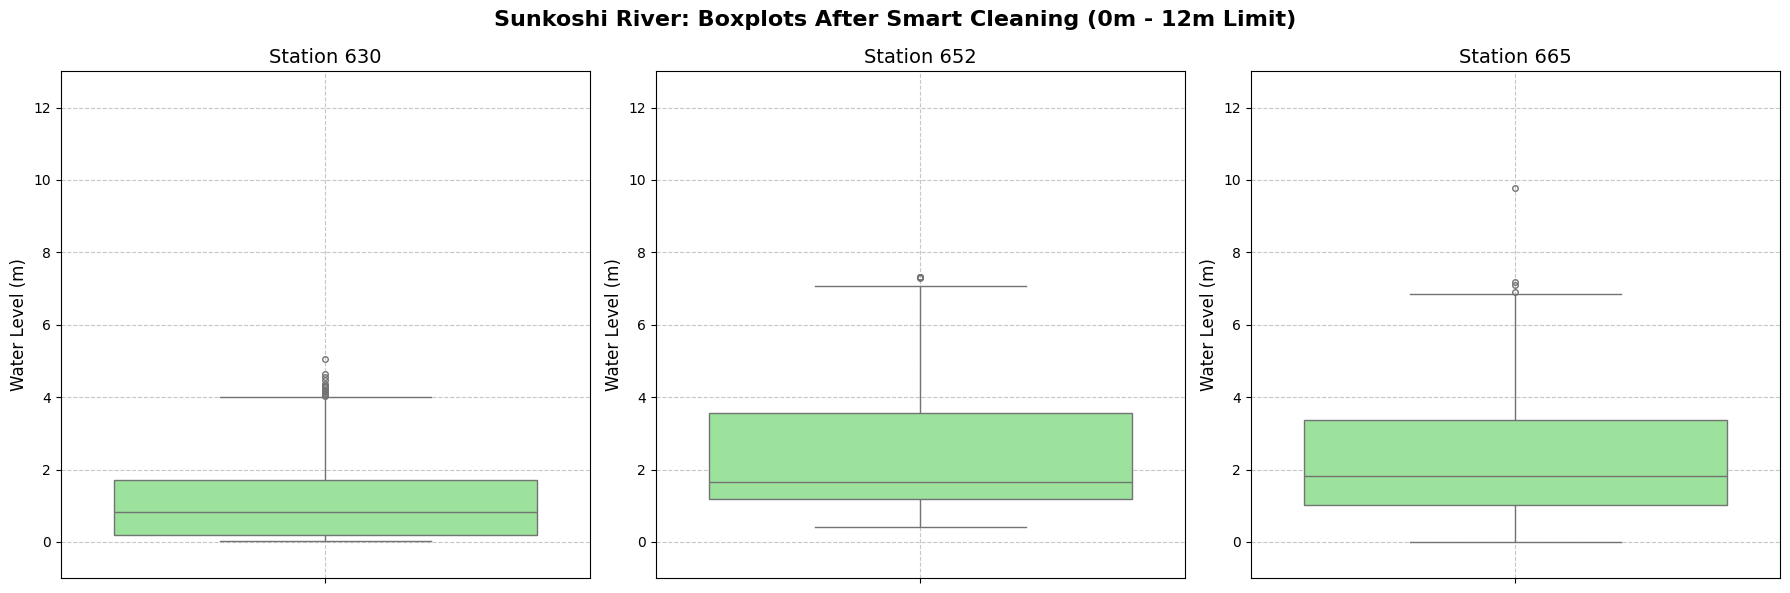


--- FINAL NUMERICAL VERIFICATION ---
Station 630 -> Min: 0.02m | Max: 5.05m
Station 652 -> Min: 0.40m | Max: 7.33m
Station 665 -> Min: 0.01m | Max: 9.79m


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VERIFYING CLEAN DATA WITH BOXPLOTS ---")

# Eutai figure ma 3 wata plot banaune setup
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sunkoshi River: Boxplots After Smart Cleaning (0m - 12m Limit)', fontsize=16, fontweight='bold')

# Dictionary ko keys (station IDs) nikalne
stations = list(sunkoshi_raw_data.keys())

for i, station_id in enumerate(stations):
    df_clean = sunkoshi_raw_data[station_id]
    
    # Boxplot draw garne
    sns.boxplot(y=df_clean['value'], ax=axes[i], color='lightgreen', fliersize=4)
    
    # Graph ko design milaune
    axes[i].set_title(f'Station {station_id}', fontsize=14)
    axes[i].set_ylabel('Water Level (m)', fontsize=12)
    
    # Y-axis lai thakkai -1 dekhi 13 samma lock garne taaki 0-12 ko range majjale dekhayos
    axes[i].set_ylim(-1, 13) 
    
    # Grid thapne easy reading ko lagi
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print a quick text summary to confirm max/min numerically
print("\n--- FINAL NUMERICAL VERIFICATION ---")
for station_id in stations:
    df_clean = sunkoshi_raw_data[station_id]
    print(f"Station {station_id} -> Min: {df_clean['value'].min():.2f}m | Max: {df_clean['value'].max():.2f}m")

In [15]:
import pandas as pd
import numpy as np

print("--- STEP 3: FORCING UNIFORM TIMELINE (Exposing Hidden Gaps) ---")

for station_id, df in sunkoshi_raw_data.items():
    # 1. Station ko purano stats note garne
    original_len = len(df)
    start_date = df.index.min()
    end_date = df.index.max()
    
    # 2. Perfect continuous daily calendar banaune (Start to End)
    full_timeline = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # 3. Data lai tyo perfect calendar sanga align (reindex) garne
    # Jun dates paila thiyena, tyaha aafai NaN aayera bascha
    df_uniform = df.reindex(full_timeline)
    df_uniform.index.name = 'dateTime'
    
    # 4. Dictionary ma clean uniform data update garne
    sunkoshi_raw_data[station_id] = df_uniform
    
    # 5. Report Print Garne
    uniform_len = len(df_uniform)
    hidden_gaps = uniform_len - original_len
    total_nans = df_uniform['value'].isna().sum()
    
    print(f"\n==========================================")
    print(f"🗓️ STATION {station_id} TIMELINE REPORT")
    print(f"==========================================")
    print(f"Timeline Date Range : {start_date.date()} to {end_date.date()}")
    print(f"Original Days Count : {original_len}")
    print(f"Perfect Days Count  : {uniform_len}")
    print(f"Hidden Gaps Exposed : {hidden_gaps} days (Now NaN)")
    print(f"Total NaNs in data  : {total_nans} (Outliers + Gaps)")

print("\n-----------------------------------------------------------")
print("✅ Phase 3 Complete: All stations are now mapped to a perfect daily calendar!")
print("-----------------------------------------------------------")

--- STEP 3: FORCING UNIFORM TIMELINE (Exposing Hidden Gaps) ---

🗓️ STATION 630 TIMELINE REPORT
Timeline Date Range : 2010-01-01 to 2019-12-31
Original Days Count : 3652
Perfect Days Count  : 3652
Hidden Gaps Exposed : 0 days (Now NaN)
Total NaNs in data  : 219 (Outliers + Gaps)

🗓️ STATION 652 TIMELINE REPORT
Timeline Date Range : 2006-01-01 to 2019-12-31
Original Days Count : 5113
Perfect Days Count  : 5113
Hidden Gaps Exposed : 0 days (Now NaN)
Total NaNs in data  : 1507 (Outliers + Gaps)

🗓️ STATION 665 TIMELINE REPORT
Timeline Date Range : 2019-05-19 to 2026-06-15
Original Days Count : 2585
Perfect Days Count  : 2585
Hidden Gaps Exposed : 0 days (Now NaN)
Total NaNs in data  : 241 (Outliers + Gaps)

-----------------------------------------------------------
✅ Phase 3 Complete: All stations are now mapped to a perfect daily calendar!
-----------------------------------------------------------


In [16]:
import numpy as np
import pandas as pd

print("--- STEP 4: SMART INTERPOLATION & CHUNKING ONLY ---")

gap_limit_days = 7
time_step = 10 

# Naya dictionary jasma harek station ko aafnai chunks haru safe baschan
sunkoshi_chunks_dict = {}

for station_id, df in sunkoshi_raw_data.items():
    print(f"\nProcessing Station {station_id}...")
    
    # 1. INTERPOLATION (Max 7 days)
    initial_nans = df['value'].isna().sum()
    df['value'] = df['value'].interpolate(method='linear', limit=gap_limit_days)
    remaining_nans = df['value'].isna().sum()
    print(f" -> Interpolated {initial_nans - remaining_nans} small gaps.")
    print(f" -> Remaining large NaNs (Cut points): {remaining_nans}")
    
    # 2. CHUNKING ALGORITHM (Breaking at remaining NaNs)
    station_chunks = []
    current_chunk = []
    
    for val in df['value'].values:
        if pd.notna(val):
            current_chunk.append(val)
        else:
            if len(current_chunk) > time_step:
                station_chunks.append(np.array(current_chunk))
            current_chunk = [] # Reset for next block
            
    # Check for the last remaining chunk after the loop ends
    if len(current_chunk) > time_step:
        station_chunks.append(np.array(current_chunk))
        
    # Safely store chunks in the new dictionary
    sunkoshi_chunks_dict[station_id] = station_chunks
    
    print(f" -> Chunking complete: Generated {len(station_chunks)} safe chunks.")
    # Sano preview matra dekhaune
    for i in range(min(3, len(station_chunks))):
        print(f"    - Chunk {i+1} length: {len(station_chunks[i])} days")

print("\n-----------------------------------------------------------")
print("✅ Step 4 Complete: All stations are interpolated and safely chunked!")
print("-----------------------------------------------------------")

--- STEP 4: SMART INTERPOLATION & CHUNKING ONLY ---

Processing Station 630...
 -> Interpolated 28 small gaps.
 -> Remaining large NaNs (Cut points): 191
 -> Chunking complete: Generated 4 safe chunks.
    - Chunk 1 length: 1453 days
    - Chunk 2 length: 80 days
    - Chunk 3 length: 907 days

Processing Station 652...
 -> Interpolated 7 small gaps.
 -> Remaining large NaNs (Cut points): 1500
 -> Chunking complete: Generated 2 safe chunks.
    - Chunk 1 length: 1422 days
    - Chunk 2 length: 2191 days

Processing Station 665...
 -> Interpolated 26 small gaps.
 -> Remaining large NaNs (Cut points): 215
 -> Chunking complete: Generated 4 safe chunks.
    - Chunk 1 length: 514 days
    - Chunk 2 length: 1619 days
    - Chunk 3 length: 183 days

-----------------------------------------------------------
✅ Step 4 Complete: All stations are interpolated and safely chunked!
-----------------------------------------------------------


In [17]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("--- STEP 5 & 6: LEAK-PROOF SPLIT, SCALING & SEQUENCING FOR SUNKOSHI ---")

# HELPER FUNCTIONS (Same safe logic we used for Bagmati)
def split_chunks_chronologically(chunks_list, split_ratio=0.8):
    total_days = sum(len(c) for c in chunks_list)
    split_point = int(total_days * split_ratio)
    train_chunks, test_chunks = [], []
    current_days = 0
    
    for chunk in chunks_list:
        chunk_len = len(chunk)
        if current_days + chunk_len <= split_point:
            train_chunks.append(chunk)
            current_days += chunk_len
        elif current_days < split_point:
            cut_idx = split_point - current_days
            train_chunks.append(chunk[:cut_idx])
            test_chunks.append(chunk[cut_idx:])
            current_days += chunk_len
        else:
            test_chunks.append(chunk)
    return train_chunks, test_chunks

def extract_windows(scaled_chunks_list, time_step):
    X_list, y_list = [], []
    for chunk in scaled_chunks_list:
        if len(chunk) > time_step:
            for i in range(len(chunk) - time_step):
                X_list.append(chunk[i:(i + time_step), 0])
                y_list.append(chunk[i + time_step, 0])
    return np.array(X_list), np.array(y_list)

time_step = 10
# Naya Vault jasma Sunkoshi ko sabai station ko isolated Train/Test data ra Scalers baschan
sunkoshi_vault = {} 

for station_id, station_chunks in sunkoshi_chunks_dict.items():
    print(f"\n==========================================")
    print(f"⚙️ PROCESSING STATION: {station_id}")
    
    # 1. TIME-KNIFE SPLIT (80% Train, 20% Test)
    train_chunks, test_chunks = split_chunks_chronologically(station_chunks, split_ratio=0.85)
    
    # 2. LEAK-PROOF NORMALIZATION (Independent for this station)
    train_combined = np.concatenate(train_chunks).reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_combined) # Fitting only on PAST data!
    
    scaled_train_chunks = [scaler.transform(c.reshape(-1, 1)) for c in train_chunks]
    scaled_test_chunks = [scaler.transform(c.reshape(-1, 1)) for c in test_chunks]
    
    # 3. SEQUENCE EXTRACTION
    X_train, y_train = extract_windows(scaled_train_chunks, time_step)
    X_test, y_test = extract_windows(scaled_test_chunks, time_step)
    
    # LSTM ko lagi 3D shape ma laijane
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    if len(X_test) > 0:
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # 4. STORE IN STATION VAULT
    sunkoshi_vault[station_id] = {
        'train': (X_train, y_train),
        'test': (X_test, y_test),
        'scaler': scaler
    }
    
    print(f" -> Train Sequences : {len(X_train)}")
    print(f" -> Test Sequences  : {len(X_test)}")
    print(f" -> Scaler Fits     : Min={scaler.data_min_[0]:.2f}, Max={scaler.data_max_[0]:.2f}")

print("\n-----------------------------------------------------------")
print("✅ SUNKOSHI VAULT SECURED: All 3 stations are leak-proofed & sequenced!")
print("-----------------------------------------------------------")

# RAM free garna ko lagi purano variables falne
del sunkoshi_chunks_dict

--- STEP 5 & 6: LEAK-PROOF SPLIT, SCALING & SEQUENCING FOR SUNKOSHI ---

⚙️ PROCESSING STATION: 630
 -> Train Sequences : 2901
 -> Test Sequences  : 510
 -> Scaler Fits     : Min=0.02, Max=4.55

⚙️ PROCESSING STATION: 652
 -> Train Sequences : 3051
 -> Test Sequences  : 532
 -> Scaler Fits     : Min=0.40, Max=7.33

⚙️ PROCESSING STATION: 665
 -> Train Sequences : 1994
 -> Test Sequences  : 326
 -> Scaler Fits     : Min=0.48, Max=9.79

-----------------------------------------------------------
✅ SUNKOSHI VAULT SECURED: All 3 stations are leak-proofed & sequenced!
-----------------------------------------------------------


In [23]:
import pandas as pd
import numpy as np
import io

print("--- STEP 1: LOAD, CLEAN & UNIFORM TIMELINE (LIKHU & KOKHAJOR) ---")

# Timro text files ko exact Kaggle names halnu hai
extra_stations = {
    'likhu': '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_660.txt',      
    'kokhajor': '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_580.txt' 
}

# Yesma hamro clean uniform data bascha
extra_rivers_raw_data = {}
ABSOLUTE_MAX = 15.0 # Khola ko lagi 15m vanda mathi 100% glitch ho

for name, filepath in extra_stations.items():
    print(f"\n🌊 Processing {name.upper()}...")
    try:
        # 1. Text bata kachara hatayera load garne
        with open(filepath, 'r') as file:
            clean_lines = [line for line in file.readlines() if ',' in line]
        df = pd.read_csv(io.StringIO("".join(clean_lines)), header=None, names=['dateTime', 'value'])
        
        # 2. Date ra numbers milaune
        df['dateTime'] = pd.to_datetime(df['dateTime'], format='%d/%b/%Y', errors='coerce')
        df.dropna(subset=['dateTime', 'value'], inplace=True)
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df.set_index('dateTime', inplace=True)
        df.sort_index(inplace=True)
        
        # 3. Daily Mean (Harmonization) ra Glitch Removal (<=0 ya >15m)
        df_daily = df[['value']].resample('D').mean()
        outliers = (df_daily['value'] <= 0.0) | (df_daily['value'] > ABSOLUTE_MAX)
        df_daily.loc[outliers, 'value'] = np.nan
        
        # 4. Forcing Perfect Uniform Calendar
        start_date = df_daily.index.min()
        end_date = df_daily.index.max()
        full_timeline = pd.date_range(start=start_date, end=end_date, freq='D')
        df_uniform = df_daily.reindex(full_timeline)
        df_uniform.index.name = 'dateTime'
        
        # Safe dict ma save garne
        extra_rivers_raw_data[name] = df_uniform
        
        print(f" -> Timeline: {start_date.date()} to {end_date.date()}")
        print(f" -> Total Days (Uniform Timeline): {len(df_uniform)}")
        print(f" -> Total Missing/NaNs (Gaps + Outliers): {df_uniform['value'].isna().sum()}")
        
    except FileNotFoundError:
        print(f" -> ❌ Error: {filepath} not found in Kaggle! Check the name.")
    except Exception as e:
        print(f" -> ❌ Error processing {name}: {e}")

print("\n-----------------------------------------------------------")
print("✅ Step 1 Complete: Likhu and Kokhajor are loaded and mapped to calendar!")
print("-----------------------------------------------------------")

--- STEP 1: LOAD, CLEAN & UNIFORM TIMELINE (LIKHU & KOKHAJOR) ---

🌊 Processing LIKHU...
 -> Timeline: 2006-01-01 to 2015-12-31
 -> Total Days (Uniform Timeline): 3652
 -> Total Missing/NaNs (Gaps + Outliers): 92

🌊 Processing KOKHAJOR...
 -> Timeline: 2021-01-01 to 2022-12-31
 -> Total Days (Uniform Timeline): 730
 -> Total Missing/NaNs (Gaps + Outliers): 0

-----------------------------------------------------------
✅ Step 1 Complete: Likhu and Kokhajor are loaded and mapped to calendar!
-----------------------------------------------------------


In [24]:
 extra_rivers_raw_data['kokhajor'].describe()

,value
count,730.000000
mean,1.418096
std,0.338760
min,1.070000
25%,1.170000
50%,1.270000
75%,1.607500
max,3.390000


In [25]:
import numpy as np
import pandas as pd

print("--- STEP 2: SMART INTERPOLATION & CHUNKING (LIKHU & KOKHAJOR) ---")

gap_limit_days = 7
time_step = 10 

# Naya dictionary jasma Likhu ra Kokhajor ko safe chunks baschan
extra_rivers_chunks_dict = {}

for station_name, df in extra_rivers_raw_data.items():
    print(f"\nProcessing {station_name.upper()}...")
    
    # 1. INTERPOLATION (Max 7 days gaps fill garne)
    initial_nans = df['value'].isna().sum()
    df['value'] = df['value'].interpolate(method='linear', limit=gap_limit_days)
    remaining_nans = df['value'].isna().sum()
    print(f" -> Interpolated {initial_nans - remaining_nans} small gaps/outliers.")
    print(f" -> Remaining large NaNs (Cut points): {remaining_nans}")
    
    # 2. CHUNKING ALGORITHM (Breaking data at large NaNs)
    station_chunks = []
    current_chunk = []
    
    for val in df['value'].values:
        if pd.notna(val):
            current_chunk.append(val)
        else:
            if len(current_chunk) > time_step:
                station_chunks.append(np.array(current_chunk))
            current_chunk = [] # Reset for next block
            
    # Loop sakiye pachi last ko chunk check garne
    if len(current_chunk) > time_step:
        station_chunks.append(np.array(current_chunk))
        
    # Dictionary ma chunks save garne
    extra_rivers_chunks_dict[station_name] = station_chunks
    
    print(f" -> Chunking complete: Generated {len(station_chunks)} safe chunks.")
    for i in range(min(3, len(station_chunks))):
        print(f"    - Chunk {i+1} length: {len(station_chunks[i])} days")

print("\n-----------------------------------------------------------")
print("✅ Step 2 Complete: Likhu and Kokhajor are safely chunked!")
print("-----------------------------------------------------------")

--- STEP 2: SMART INTERPOLATION & CHUNKING (LIKHU & KOKHAJOR) ---

Processing LIKHU...
 -> Interpolated 9 small gaps/outliers.
 -> Remaining large NaNs (Cut points): 83
 -> Chunking complete: Generated 2 safe chunks.
    - Chunk 1 length: 266 days
    - Chunk 2 length: 3303 days

Processing KOKHAJOR...
 -> Interpolated 0 small gaps/outliers.
 -> Remaining large NaNs (Cut points): 0
 -> Chunking complete: Generated 1 safe chunks.
    - Chunk 1 length: 730 days

-----------------------------------------------------------
✅ Step 2 Complete: Likhu and Kokhajor are safely chunked!
-----------------------------------------------------------


In [26]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("--- STEP 3: LEAK-PROOF SPLIT, SCALING & SEQUENCES ---")

# HELPER FUNCTIONS
def split_chunks_chronologically(chunks_list, split_ratio=0.8):
    total_days = sum(len(c) for c in chunks_list)
    split_point = int(total_days * split_ratio)
    train_chunks, test_chunks = [], []
    current_days = 0
    
    for chunk in chunks_list:
        chunk_len = len(chunk)
        if current_days + chunk_len <= split_point:
            train_chunks.append(chunk)
            current_days += chunk_len
        elif current_days < split_point:
            cut_idx = split_point - current_days
            train_chunks.append(chunk[:cut_idx])
            test_chunks.append(chunk[cut_idx:])
            current_days += chunk_len
        else:
            test_chunks.append(chunk)
    return train_chunks, test_chunks

def extract_windows(scaled_chunks_list, time_step):
    X_list, y_list = [], []
    for chunk in scaled_chunks_list:
        if len(chunk) > time_step:
            for i in range(len(chunk) - time_step):
                X_list.append(chunk[i:(i + time_step), 0])
                y_list.append(chunk[i + time_step, 0])
    return np.array(X_list), np.array(y_list)

time_step = 10
# Naya Vault jasma Likhu ra Kokhajor ko Train/Test sequences ra Scalers baschan
extra_rivers_vault = {} 

for station_id, station_chunks in extra_rivers_chunks_dict.items():
    print(f"\n==========================================")
    print(f"⚙️ PROCESSING {station_id.upper()}")
    
    # 1. TIME-KNIFE SPLIT (80% Train, 20% Test)
    train_chunks, test_chunks = split_chunks_chronologically(station_chunks, split_ratio=0.8)
    
    # 2. LEAK-PROOF NORMALIZATION (Independent for this station)
    train_combined = np.concatenate(train_chunks).reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_combined) # Fits ONLY on Train data
    
    scaled_train_chunks = [scaler.transform(c.reshape(-1, 1)) for c in train_chunks]
    scaled_test_chunks = [scaler.transform(c.reshape(-1, 1)) for c in test_chunks]
    
    # 3. SEQUENCE EXTRACTION (10-Day Lag)
    X_train, y_train = extract_windows(scaled_train_chunks, time_step)
    X_test, y_test = extract_windows(scaled_test_chunks, time_step)
    
    # Reshape for LSTM (3D format)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    if len(X_test) > 0:
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # 4. STORE IN EXTRA RIVERS VAULT
    extra_rivers_vault[station_id] = {
        'train': (X_train, y_train),
        'test': (X_test, y_test),
        'scaler': scaler
    }
    
    print(f" -> Train Sequences : {len(X_train)}")
    print(f" -> Test Sequences  : {len(X_test)}")
    print(f" -> Scaler Fits     : Min={scaler.data_min_[0]:.2f}, Max={scaler.data_max_[0]:.2f}")

print("\n-----------------------------------------------------------")
print("✅ EXTRA RIVERS VAULT SECURED: Likhu and Kokhajor are leak-proofed & sequenced!")
print("-----------------------------------------------------------")

# Free up memory (Memory Management is crucial in ML)
del extra_rivers_raw_data
del extra_rivers_chunks_dict

--- STEP 3: LEAK-PROOF SPLIT, SCALING & SEQUENCES ---

⚙️ PROCESSING LIKHU
 -> Train Sequences : 2835
 -> Test Sequences  : 704
 -> Scaler Fits     : Min=0.64, Max=3.98

⚙️ PROCESSING KOKHAJOR
 -> Train Sequences : 574
 -> Test Sequences  : 136
 -> Scaler Fits     : Min=1.07, Max=3.39

-----------------------------------------------------------
✅ EXTRA RIVERS VAULT SECURED: Likhu and Kokhajor are leak-proofed & sequenced!
-----------------------------------------------------------
